In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv("/content/Training_data.csv")
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


In [3]:
data.isna().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [4]:
data.isna().mean()*100

,0
customerID,0.000000
gender,2.999645
SeniorCitizen,0.000000
Partner,0.000000
Dependents,0.000000
tenure,0.000000
PhoneService,0.000000
MultipleLines,0.000000
InternetService,0.000000
OnlineSecurity,2.999645


In [5]:
data.duplicated().sum()

np.int64(0)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


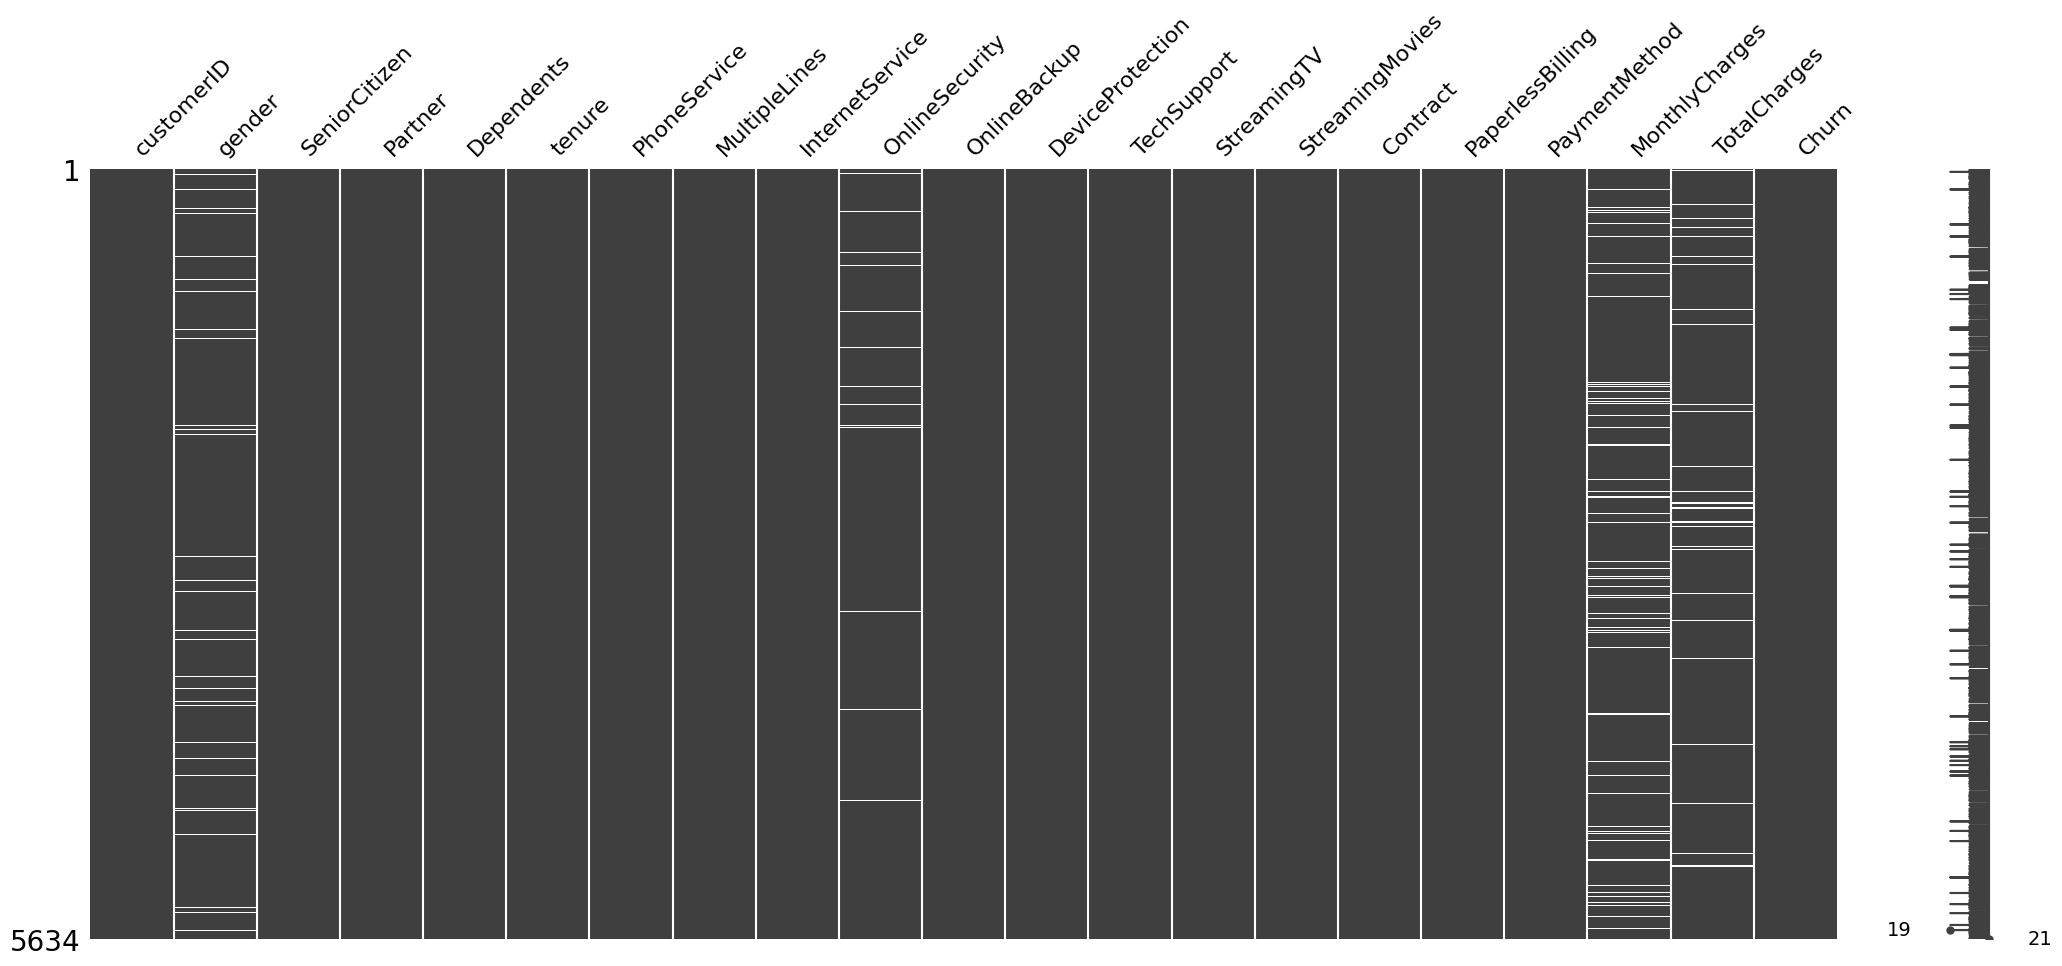

In [7]:
import missingno as msno
msno.matrix(data)
plt.show()

In [8]:
data["gender"].value_counts(dropna=False)

,count
gender,
Male,2744
Female,2721
NaN,169


In [9]:
data["gender"].fillna(data["gender"].mode()[0], inplace=True)

/tmp/ipykernel_19858/298294092.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["gender"].fillna(data["gender"].mode()[0], inplace=True)


In [10]:
data["OnlineSecurity"].value_counts(dropna=False)

,count
OnlineSecurity,
No,2720
Yes,1574
No internet service,1171
NaN,169


In [11]:
data["SeniorCitizen"].value_counts(dropna=False)

,count
SeniorCitizen,
0,4734
1,900


In [12]:
data["TotalCharges"].value_counts(dropna=False)

,count
TotalCharges,
NaN,281
,9
20.2,8
19.65,8
19.9,7
...,...
5311.85,1
342.3,1
1313.55,1


In [13]:
data["TotalCharges"].dtype

dtype('O')

In [14]:
data["TotalCharges"].head(10)

,TotalCharges
0,700.45
1,961.4
2,5581.05
3,790
4,2151.6
5,4040.65
6,34.75
7,1633
8,6871.7
9,NaN


In [15]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

In [16]:
data["TotalCharges"].dtype

dtype('float64')

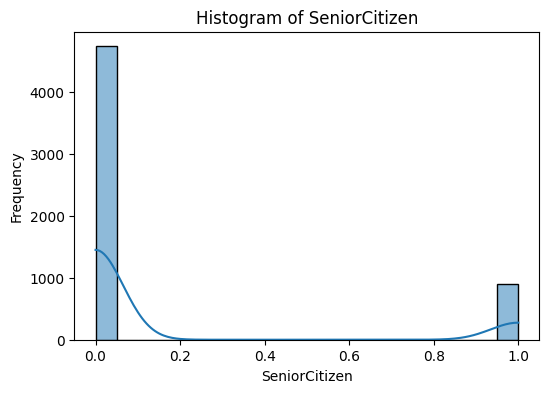

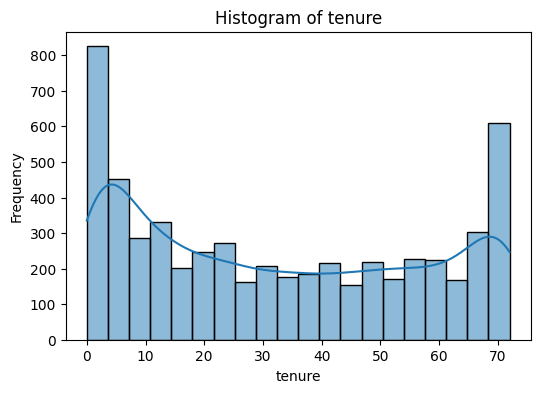

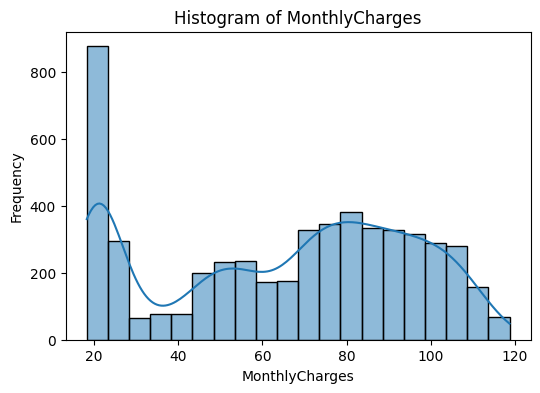

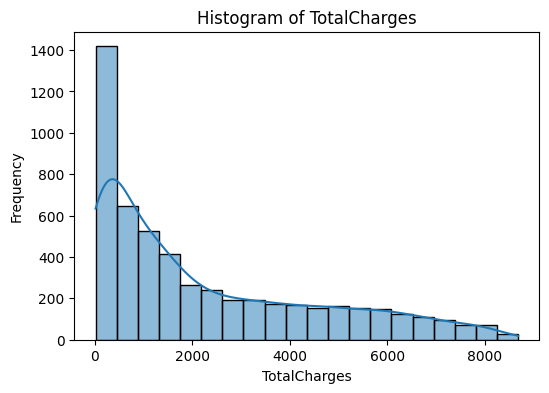

In [17]:
columns = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

for col in columns:
    plt.figure(figsize=(6,4))
    sns.histplot(data[col], bins=20, kde=True)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [18]:
data["OnlineSecurity"] = data["OnlineSecurity"].fillna(data["OnlineSecurity"].mode()[0])

In [19]:
data["MonthlyCharges"] = data["MonthlyCharges"].fillna(data["MonthlyCharges"].mean())
data["TotalCharges"] = data["TotalCharges"].fillna(data["TotalCharges"].mean())

In [20]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


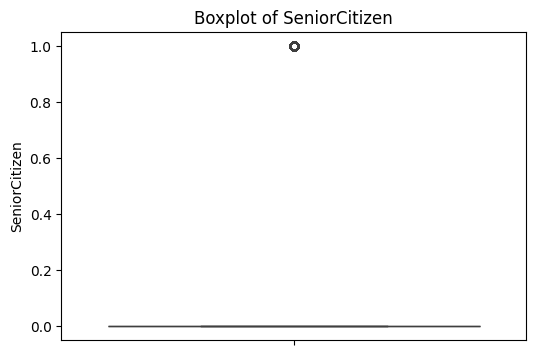

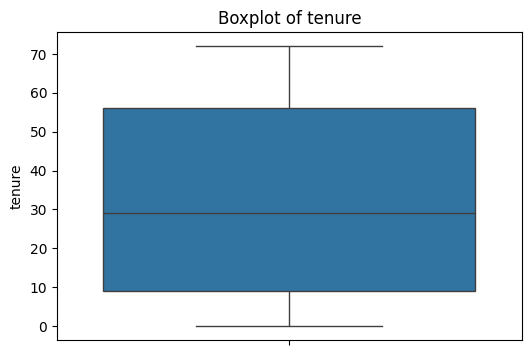

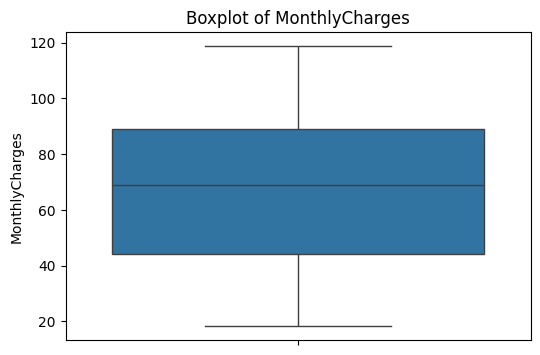

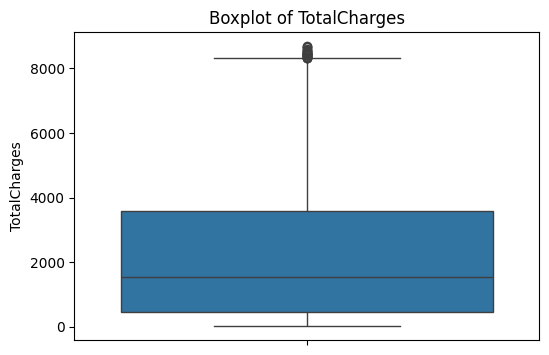

In [21]:
columns = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

for col in columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=data[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [22]:
from scipy.stats.mstats import winsorize

In [23]:
data["TotalCharges"] = winsorize(data["TotalCharges"], limits=[0.01, 0.01])

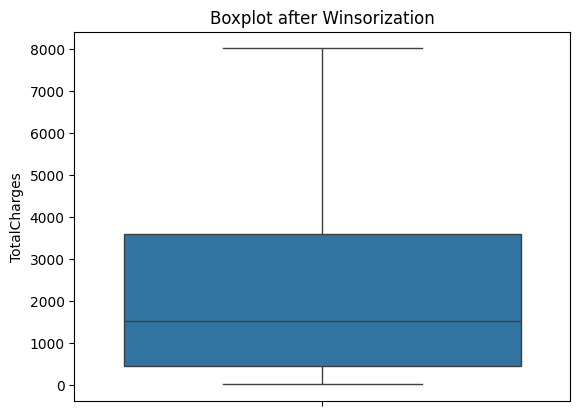

In [24]:
sns.boxplot(y=data["TotalCharges"])
plt.title("Boxplot after Winsorization")
plt.show()

In [25]:
cat_cols = data.select_dtypes(include="object").columns
print(cat_cols)

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')


In [26]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.40,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790.00,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,No,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.60,No


In [27]:
from sklearn.preprocessing import LabelEncoder   #these are binary columns

le = LabelEncoder()

binary_cols = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "Churn"
]

for col in binary_cols:
    data[col] = le.fit_transform(data[col])

In [28]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,0,0,0,0,35,1,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,0,Mailed check,20.75,700.45,0
1,7746-AWNQW,0,0,0,0,28,0,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,1,Mailed check,35.75,961.40,0
2,2208-UGTGR,1,0,0,0,56,1,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,0,Electronic check,98.60,5581.05,0
3,4884-LEVMQ,1,0,1,0,39,1,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,1,Bank transfer (automatic),20.45,790.00,0
4,6682-VCIXC,0,0,1,1,43,0,No phone service,DSL,No,...,No,Yes,Yes,No,One year,1,Bank transfer (automatic),51.25,2151.60,0


In [29]:
data["MultipleLines"].value_counts(dropna=False)

,count
MultipleLines,
No,2701
Yes,2380
No phone service,553


In [30]:
data["InternetService"].value_counts(dropna=False)

,count
InternetService,
Fiber optic,2486
DSL,1945
No,1203


In [31]:
data["OnlineSecurity"].value_counts(dropna=False)

,count
OnlineSecurity,
No,2889
Yes,1574
No internet service,1171


In [32]:
data["OnlineBackup"].value_counts(dropna=False)

,count
OnlineBackup,
No,2459
Yes,1972
No internet service,1203


In [33]:
data["DeviceProtection"].value_counts(dropna=False)

,count
DeviceProtection,
No,2485
Yes,1946
No internet service,1203


In [34]:
data["TechSupport"].value_counts()

,count
TechSupport,
No,2782
Yes,1649
No internet service,1203


In [35]:
data["StreamingTV"].value_counts()

,count
StreamingTV,
No,2244
Yes,2187
No internet service,1203


In [36]:
contract_map = {
    "Month-to-month": 0,
    "One year": 1,
    "Two year": 2
}

data["Contract"] = data["Contract"].map(contract_map)

In [37]:
multi_cols = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaymentMethod"
]

data = pd.get_dummies(
    data,
    columns=multi_cols,
    drop_first=True,
    dtype=int
)

In [38]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,MonthlyCharges,...,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,9509-MPYOD,0,0,0,0,35,1,1,0,20.75,...,0,1,0,1,0,1,0,0,0,1
1,7746-AWNQW,0,0,0,0,28,0,0,1,35.75,...,1,0,1,0,0,0,0,0,0,1
2,2208-UGTGR,1,0,0,0,56,1,0,0,98.60,...,0,0,0,0,1,0,1,0,1,0
3,4884-LEVMQ,1,0,1,0,39,1,2,1,20.45,...,0,1,0,1,0,1,0,0,0,0
4,6682-VCIXC,0,0,1,1,43,0,1,1,51.25,...,0,0,1,0,1,0,0,0,0,0


In [39]:
data.drop("customerID", axis=1, inplace=True)

In [40]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,...,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,0,0,35,1,1,0,20.75,700.45,...,0,1,0,1,0,1,0,0,0,1
1,0,0,0,0,28,0,0,1,35.75,961.40,...,1,0,1,0,0,0,0,0,0,1
2,1,0,0,0,56,1,0,0,98.60,5581.05,...,0,0,0,0,1,0,1,0,1,0
3,1,0,1,0,39,1,2,1,20.45,790.00,...,0,1,0,1,0,1,0,0,0,0
4,0,0,1,1,43,0,1,1,51.25,2151.60,...,0,0,1,0,1,0,0,0,0,0


In [41]:
X = data.drop("Churn", axis=1)
y = data["Churn"]

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [43]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

LogisticRegresssion

In [44]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [45]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.8003549245785271
[[733  93]
 [132 169]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       826
           1       0.65      0.56      0.60       301

    accuracy                           0.80      1127
   macro avg       0.75      0.72      0.73      1127
weighted avg       0.79      0.80      0.80      1127



In [46]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

In [47]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

Accuracy: 0.8003549245785271


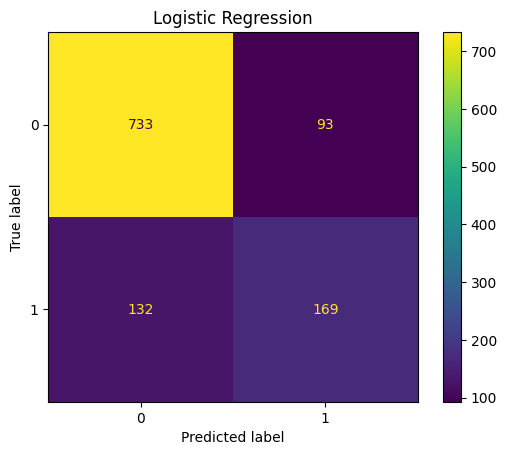

In [50]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,

)

plt.title("Logistic Regression")
plt.show()

In [51]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87       826
           1       0.65      0.56      0.60       301

    accuracy                           0.80      1127
   macro avg       0.75      0.72      0.73      1127
weighted avg       0.79      0.80      0.80      1127



In [52]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [53]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

Accuracy: 0.7426796805678794


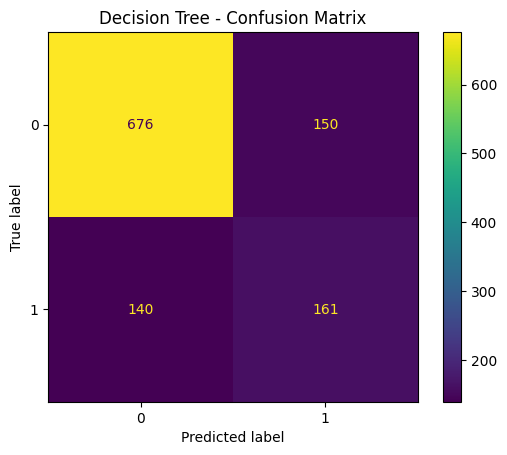

In [54]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt,

)

plt.title("Decision Tree - Confusion Matrix")
plt.show()

In [55]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.83      0.82      0.82       826
           1       0.52      0.53      0.53       301

    accuracy                           0.74      1127
   macro avg       0.67      0.68      0.67      1127
weighted avg       0.75      0.74      0.74      1127



Random Forest

In [56]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [57]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [58]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.8092280390417036


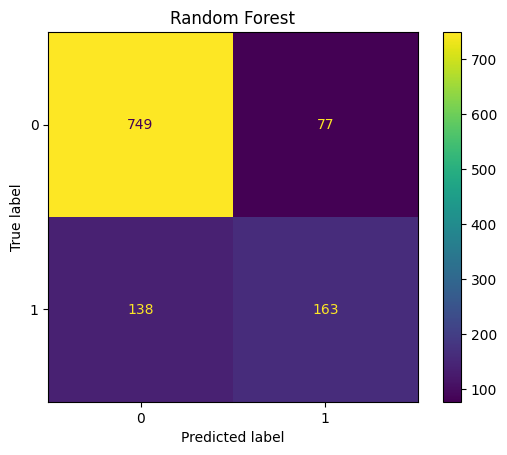

In [60]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,

)

plt.title("Random Forest")
plt.show()

In [61]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87       826
           1       0.68      0.54      0.60       301

    accuracy                           0.81      1127
   macro avg       0.76      0.72      0.74      1127
weighted avg       0.80      0.81      0.80      1127



KNN

In [62]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [63]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

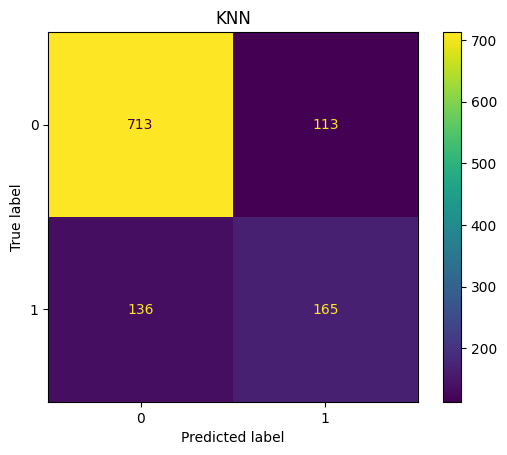

In [65]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_knn,
)

plt.title("KNN")
plt.show()

In [66]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.84      0.86      0.85       826
           1       0.59      0.55      0.57       301

    accuracy                           0.78      1127
   macro avg       0.72      0.71      0.71      1127
weighted avg       0.77      0.78      0.78      1127



In [67]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_knn)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_knn)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_knn)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.800355,0.645038,0.561462,0.600355
1,Decision Tree,0.742680,0.517685,0.534884,0.526144
2,Random Forest,0.809228,0.679167,0.541528,0.602588
3,KNN,0.779059,0.593525,0.548173,0.569948


Model Selection: Based on the comparison of Accuracy, Precision, Recall, and F1-Score, **Random Forest** was selected as the best model because it achieved the highest Accuracy (0.809), highest Precision (0.679), and highest F1-Score (0.603), indicating the best overall classification performance.

In [68]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

In [69]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [70]:
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

In [71]:
print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Score:", grid.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross Validation Score: 0.7974221793474114


In [72]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

Accuracy: 0.8118899733806566


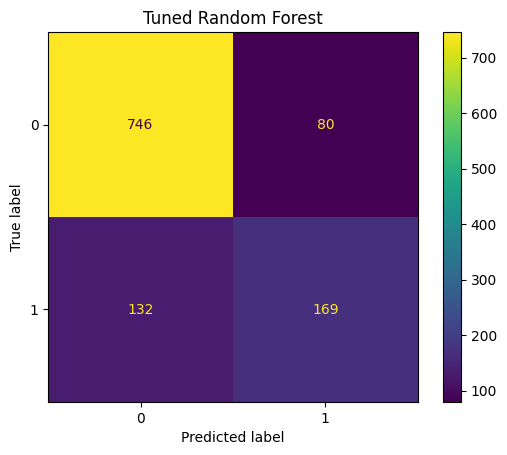

              precision    recall  f1-score   support

           0       0.85      0.90      0.88       826
           1       0.68      0.56      0.61       301

    accuracy                           0.81      1127
   macro avg       0.76      0.73      0.75      1127
weighted avg       0.80      0.81      0.81      1127



In [73]:
print("Accuracy:", accuracy_score(y_test, y_pred_best))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best)
plt.title("Tuned Random Forest")
plt.show()

print(classification_report(y_test, y_pred_best))

# Conclusion

In this project, multiple machine learning models were developed to predict customer churn. After preprocessing the data, feature engineering, and evaluating different classification models, Random Forest achieved the best overall performance.

Hyperparameter tuning using GridSearchCV further improved the Random Forest model by selecting the optimal parameter values. The tuned model achieved better classification performance than the default model.

Therefore, the tuned Random Forest model was selected as the final model for predicting customer churn. This model can help the telecommunications company identify customers who are likely to churn and take proactive retention measures.

In [74]:
test_data = pd.read_csv("Testing_data.csv")
test_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6080-TCMYC,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.3,No
1,7285-KLOTR,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,7486-KSRVI,Male,0,No,No,43,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,9924-JPRMC,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,4439-YRNVD,Female,0,No,No,10,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374,No


In [79]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            1409 non-null   object 
 1   SeniorCitizen     1409 non-null   int64  
 2   Partner           1409 non-null   object 
 3   Dependents        1409 non-null   object 
 4   tenure            1409 non-null   int64  
 5   PhoneService      1409 non-null   object 
 6   MultipleLines     1409 non-null   object 
 7   InternetService   1409 non-null   object 
 8   OnlineSecurity    1409 non-null   object 
 9   OnlineBackup      1409 non-null   object 
 10  DeviceProtection  1409 non-null   object 
 11  TechSupport       1409 non-null   object 
 12  StreamingTV       1409 non-null   object 
 13  StreamingMovies   1409 non-null   object 
 14  Contract          1409 non-null   object 
 15  PaperlessBilling  1409 non-null   object 
 16  PaymentMethod     1409 non-null   object 


In [75]:
test_data.drop("customerID", axis=1, inplace=True)

In [76]:
test_data["TotalCharges"] = pd.to_numeric(
    test_data["TotalCharges"],
    errors="coerce"
)

In [77]:
test_data.isna().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [78]:
test_data["TotalCharges"].value_counts()

,count
TotalCharges,
20.05,4
20.20,3
69.55,3
69.90,3
19.85,2
...,...
3182.95,1
20.15,1
165.45,1


In [80]:
test_data["TotalCharges"].fillna(test_data["TotalCharges"].median(), inplace=True)

/tmp/ipykernel_19858/3464961114.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_data["TotalCharges"].fillna(test_data["TotalCharges"].median(), inplace=True)


In [82]:
test_data.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [83]:
test_data["Contract"] = test_data["Contract"].map({
    "Month-to-month": 0,
    "One year": 1,
    "Two year": 2
})

In [84]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

binary_cols = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "Churn"
]

for col in binary_cols:
    test_data[col] = le.fit_transform(test_data[col])

In [85]:
multi_cols = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaymentMethod"
]

test_data = pd.get_dummies(
    test_data,
    columns=multi_cols,
    drop_first=True,
    dtype=int
)

In [86]:
test_data = test_data.reindex(columns=X.columns, fill_value=0)

In [87]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

test_data[num_cols] = scaler.transform(test_data[num_cols])

In [88]:
predictions = best_model.predict(test_data)

predictions

array([1, 0, 0, ..., 1, 0, 0])

In [89]:
test_data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,...,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,1,0.555556,1,0,1,0.626368,0.409219,...,1,0,0,0,0,0,0,0,1,0
1,0,0,1,0,0.166667,1,1,0,0.602985,0.107150,...,1,0,0,0,1,0,1,0,1,0
2,1,0,0,0,0.597222,1,1,1,0.813433,0.524172,...,0,0,1,0,1,0,1,0,1,0
3,1,0,0,0,1.000000,1,2,1,0.994527,1.066346,...,1,0,1,0,1,0,1,0,1,0
4,0,0,0,0,0.138889,0,0,0,0.179104,0.044281,...,0,0,1,0,0,0,0,0,1,0


In [90]:
test_data["Predicted_Churn"] = predictions

In [91]:
test_data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Predicted_Churn
0,1,0,1,1,0.555556,1,0,1,0.626368,0.409219,...,0,0,0,0,0,0,0,1,0,1
1,0,0,1,0,0.166667,1,1,0,0.602985,0.107150,...,0,0,0,1,0,1,0,1,0,0
2,1,0,0,0,0.597222,1,1,1,0.813433,0.524172,...,0,1,0,1,0,1,0,1,0,0
3,1,0,0,0,1.000000,1,2,1,0.994527,1.066346,...,0,1,0,1,0,1,0,1,0,0
4,0,0,0,0,0.138889,0,0,0,0.179104,0.044281,...,0,1,0,0,0,0,0,1,0,0


In [92]:
test_data.to_csv("Predicted_Test_Data.csv", index=False)

In [93]:
test_data["Predicted_Churn"].value_counts()

,count
Predicted_Churn,
0,1104
1,305


In [94]:
original_test = pd.read_csv("Testing_data.csv")

test_data["customerID"] = original_test["customerID"]

test_data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Predicted_Churn,customerID
0,1,0,1,1,0.555556,1,0,1,0.626368,0.409219,...,0,0,0,0,0,0,1,0,1,6080-TCMYC
1,0,0,1,0,0.166667,1,1,0,0.602985,0.107150,...,0,0,1,0,1,0,1,0,0,7285-KLOTR
2,1,0,0,0,0.597222,1,1,1,0.813433,0.524172,...,1,0,1,0,1,0,1,0,0,7486-KSRVI
3,1,0,0,0,1.000000,1,2,1,0.994527,1.066346,...,1,0,1,0,1,0,1,0,0,9924-JPRMC
4,0,0,0,0,0.138889,0,0,0,0.179104,0.044281,...,1,0,0,0,0,0,1,0,0,4439-YRNVD


In [96]:
test_data.to_csv("Predicted_Test_Data.csv", index=False)
